03_analysis.ipynb

Purpose:

Merge MOS and features
EDA
Correlation analysis
Linear Regression

In [18]:
import sqlite3

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.preprocessing import StandardScaler

Create Analysis Table

In [19]:
conn = sqlite3.connect(
    "../data/processed/system_data.db"
)

In [20]:
conn.execute(
"""
DROP TABLE IF EXISTS wav_analysis
"""
)

In [22]:
conn.execute(
"""
CREATE TABLE wav_analysis AS
SELECT
    w.*,
    m.MOS
FROM wav_attribute w
INNER JOIN load_raw_mos m
ON w.file = m.file
"""
)

conn.commit()

OperationalError: table wav_analysis already exists

Load Analysis Data

In [23]:
df = pd.read_sql(
    "SELECT * FROM wav_analysis",
    conn
)

df.head()

,file,duration,spectral_rolloff,spectral_contrast,silence_ratio,pitch_mean,pitch_std,pitch_min,pitch_max,pitch_range,energy_mean,energy_std,energy_range,spectral_centroid,spectral_bandwidth,zcr,MOS
0,sysc382e-uttcbd8617.wav,4.935000,3686.743952,17.951794,0.157042,262.214969,91.436661,54.566628,352.187805,297.621176,0.038453,0.027381,0.143108,2082.327697,1566.831201,0.143882,1.250
1,sys05205-utta21631b.wav,2.610063,3374.047256,19.893332,0.178564,253.239859,91.752260,50.229029,400.909091,350.680062,0.038927,0.026585,0.099773,1901.424400,1475.499787,0.165307,2.125
2,sys9e6de-utt9543789.wav,3.825375,2448.502604,19.831247,0.222037,262.346567,99.408117,50.000000,385.133195,335.133195,0.037775,0.028923,0.126565,1274.863814,1400.967827,0.078316,3.125
3,syseba96-utt04ec954.wav,2.282688,3765.082465,22.258781,0.242998,221.760204,80.087602,50.000000,377.727806,327.727806,0.037197,0.028310,0.110955,2196.692779,1759.131452,0.194756,4.125
4,sys94e9f-utt0c88a0a.wav,4.991437,4152.093349,19.284805,0.416601,225.209878,92.166091,53.964831,400.909091,346.944260,0.028692,0.030125,0.115645,2124.335687,1804.210904,0.153787,3.750


Figure 1

MOS Distribution

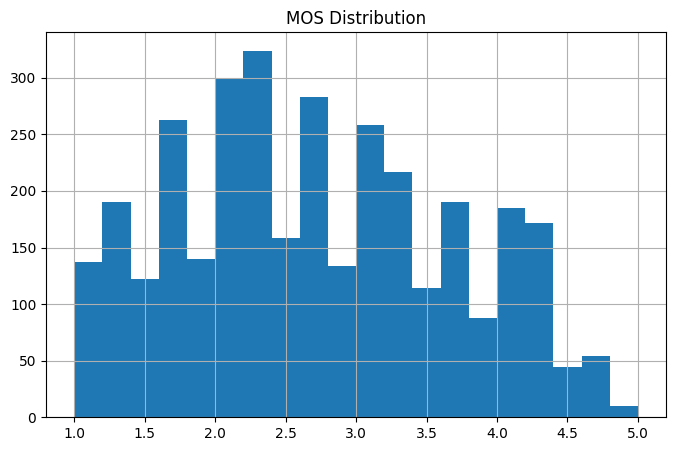

In [24]:
plt.figure(figsize=(8,5))

df["MOS"].hist(
    bins=20
)

plt.title("MOS Distribution")

plt.show()

Figure 2

Correlation Heatmap

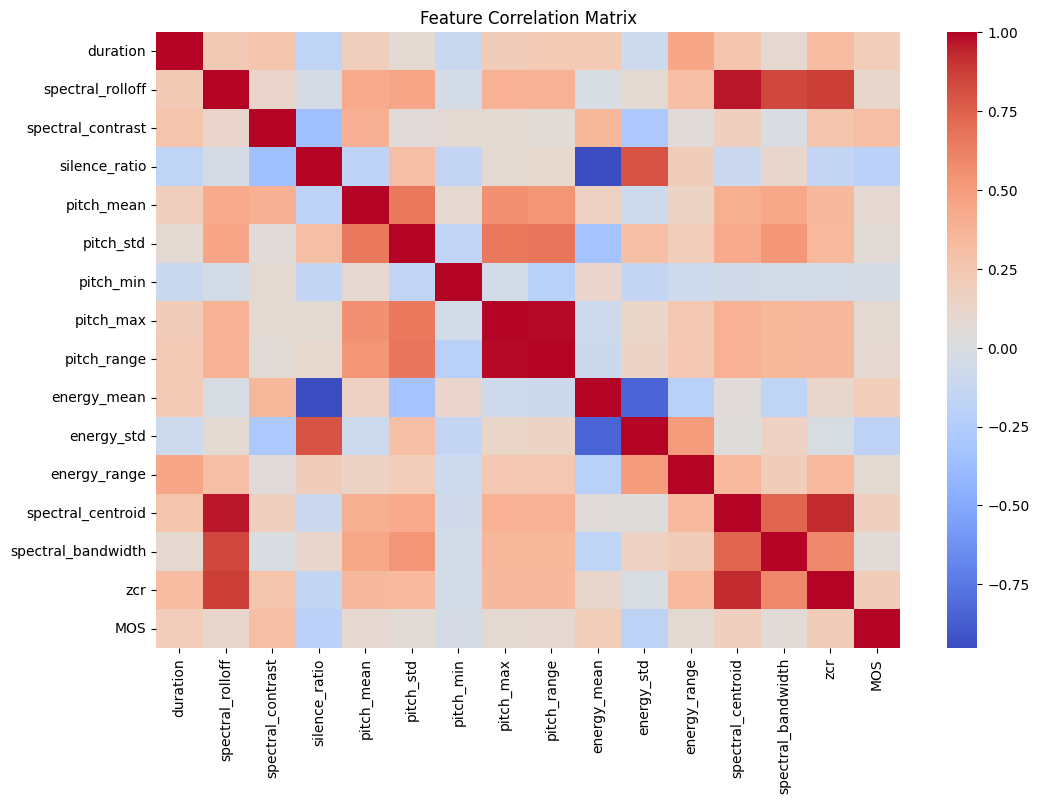

In [25]:
corr = df.corr(
    numeric_only=True
)

plt.figure(
    figsize=(12,8)
)

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

Correlation with MOS

In [26]:
corr["MOS"] \
    .sort_values(
        ascending=False
    )

MOS                   1.000000
spectral_contrast     0.313482
zcr                   0.212041
duration              0.205490
energy_mean           0.203459
spectral_centroid     0.178563
spectral_rolloff      0.111642
pitch_mean            0.089707
pitch_range           0.087706
pitch_max             0.083984
energy_range          0.076196
pitch_std             0.067098
spectral_bandwidth    0.054953
pitch_min            -0.035218
energy_std           -0.184875
silence_ratio        -0.203378
Name: MOS, dtype: float64

Figure 3

Spectral Contrast vs MOS

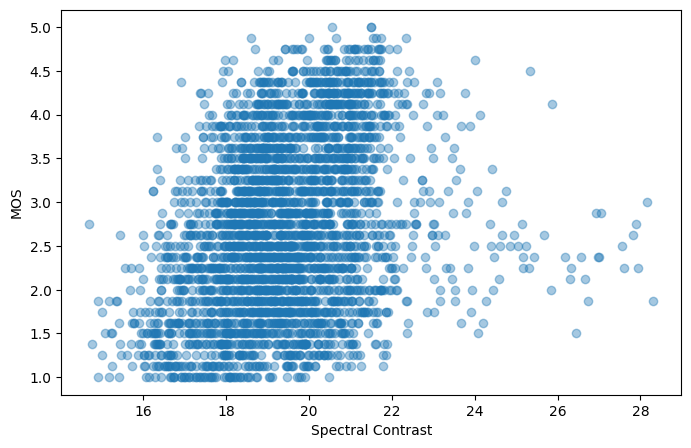

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["spectral_contrast"],
    df["MOS"],
    alpha=0.4
)

plt.xlabel(
    "Spectral Contrast"
)

plt.ylabel(
    "MOS"
)

plt.show()

Figure 4

Silence Ratio vs MOS

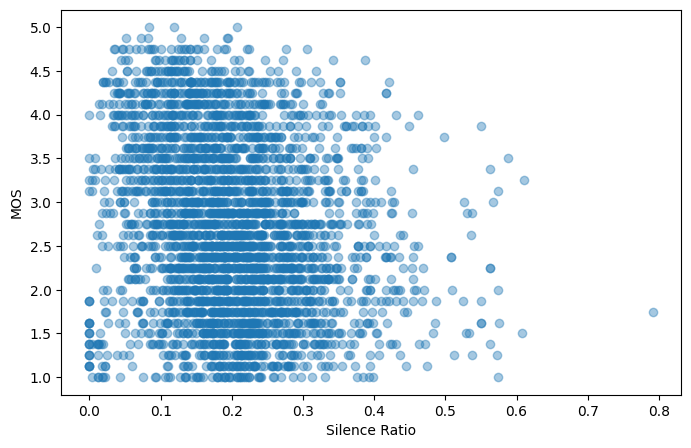

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["silence_ratio"],
    df["MOS"],
    alpha=0.4
)

plt.xlabel(
    "Silence Ratio"
)

plt.ylabel(
    "MOS"
)

plt.show()

In [28]:
print(
    df.corr(numeric_only=True)["MOS"]
    .sort_values(ascending=False)
)

MOS                   1.000000
spectral_contrast     0.313482
zcr                   0.212041
duration              0.205490
energy_mean           0.203459
spectral_centroid     0.178563
spectral_rolloff      0.111642
pitch_mean            0.089707
pitch_range           0.087706
pitch_max             0.083984
energy_range          0.076196
pitch_std             0.067098
spectral_bandwidth    0.054953
pitch_min            -0.035218
energy_std           -0.184875
silence_ratio        -0.203378
Name: MOS, dtype: float64


Linear Regression

In [10]:
X = df.drop(
    columns=[
        "file",
        "MOS"
    ]
)

y = df["MOS"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [13]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[ 0.07,-0.23, 0.21,..., 0.26, 0.04,-0.07]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.708
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,14
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](15,)","[118.68, 92.27, 67.67,..., 12.57, 6.29, 0. ]"


In [14]:
pred = model.predict(
    X_test
)

Metrics

In [15]:
print(
    "R²:",
    r2_score(
        y_test,
        pred
    )
)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )
)

R²: 0.18426716953665656
MAE: 0.7173383185070753
RMSE: 0.8687142320636432


Feature Importance

In [16]:
importance = pd.DataFrame({

    "feature":
        X.columns,

    "coefficient":
        model.coef_
})

importance = importance.sort_values(
    "coefficient",
    key=abs,
    ascending=False
)

importance

,feature,coefficient
11,spectral_rolloff,-1.067333
9,spectral_centroid,0.860441
10,spectral_bandwidth,0.285597
12,spectral_contrast,0.255844
1,pitch_mean,-0.232670
2,pitch_std,0.205941
7,energy_std,-0.181574
8,energy_range,0.093163
14,silence_ratio,-0.072540
0,duration,0.071066


Figure 5

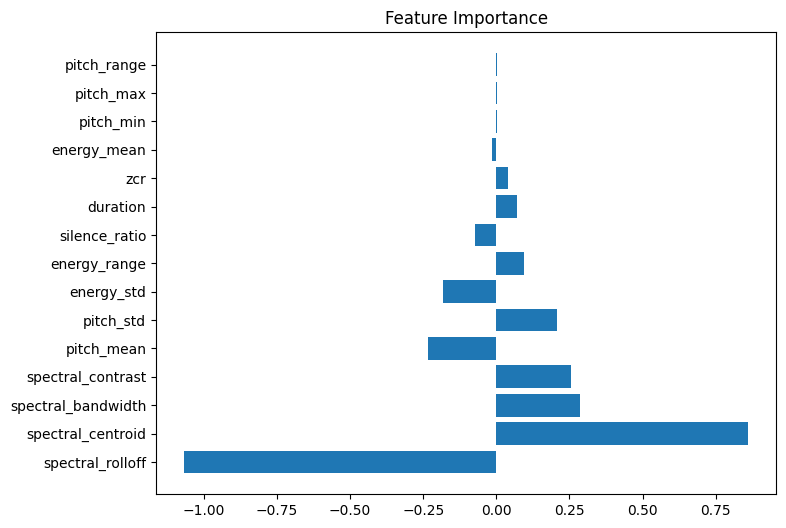

In [17]:
plt.figure(
    figsize=(8,6)
)

plt.barh(
    importance["feature"],
    importance["coefficient"]
)

plt.title(
    "Feature Importance"
)

plt.show()